In [1]:
import matplotlib.pyplot as plt
import astropy.units as u
import sunpy.data.sample
import sunpy.map
from sunpy.coordinates import SphericalScreen

# Cargamos el mapa AIA de 171 Ångstroms (Corona quieta / ~1 millón de grados Kelvin)
a171 = sunpy.map.Map(sunpy.data.sample.AIA_171_IMAGE)

# Cargamos el mapa AIA de 131 Ångstroms (Zonas activas y fulguraciones / ~10 millones de Kelvin)
a131 = sunpy.map.Map(sunpy.data.sample.AIA_131_IMAGE)


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

AIA20110607_063301_0131_lowres.fits:   0%|          | 0.00/962k [00:00<?, ?B/s]

In [2]:
with SphericalScreen(a171.observer_coordinate):
    a131 = a131.reproject_to(a171.wcs)

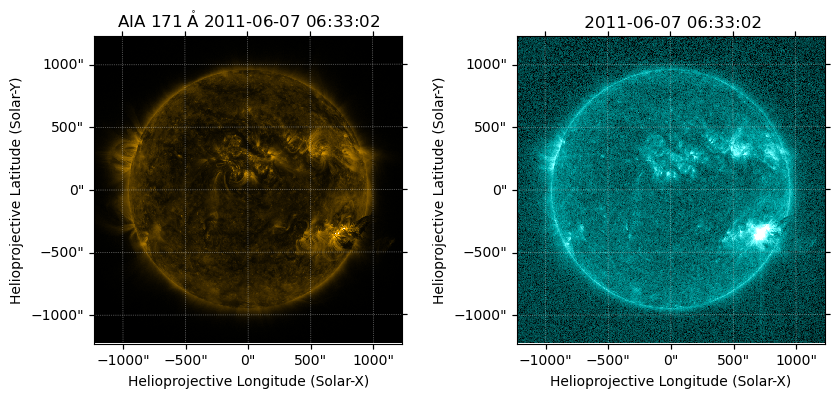

In [3]:
# 1. Creamos una figura ancha (10x4 pulgadas) con dos subgráficos de lado a lado
fig1 = plt.figure(figsize=(10, 4))
ax1 = fig1.add_subplot(121, projection=a171) # Panel izquierdo
ax2 = fig1.add_subplot(122, projection=a131) # Panel derecho

# 2. Graficamos recortando el brillo extremo (contraste automático)
a171.plot(axes=ax1, clip_interval=(1, 99.999)*u.percent)
a131.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)

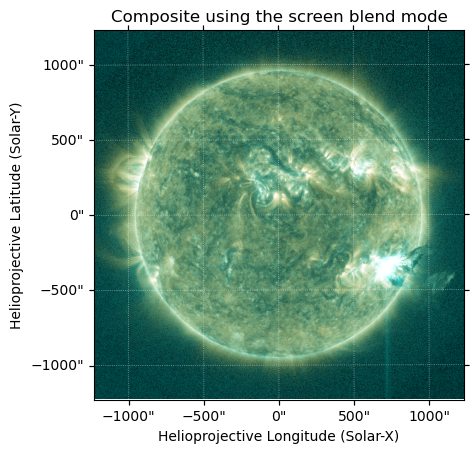

In [4]:
# 1. Creamos una nueva figura y un panel usando la geometría del mapa 171
fig2 = plt.figure()
ax = fig2.add_subplot(projection=a171)

# 2. Generamos los gráficos internamente (sin mostrarlos aún) para aplicar sus paletas de color
im171 = a171.plot(axes=ax, clip_interval=(1, 99.99)*u.percent)
im131 = a131.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)

# 3. Extraemos las matrices de píxeles en formato RGB (Rojo, Verde, Azul) escaladas de 0 a 1
renderer = fig2.canvas.get_renderer()
rgb171 = im171.make_image(renderer, unsampled=True)[0] / 255.
rgb131 = im131.make_image(renderer, unsampled=True)[0] / 255.

# 4. ¡La fórmula mágica! Modo de fusión "Screen" (Aclarar)
rgb_composite = 1 - (1 - rgb171) * (1 - rgb131)

# 5. Dibujamos el resultado final en el panel
ax.imshow(rgb_composite, origin='lower')
ax.set_title('Composite using the screen blend mode')
plt.show()